<a href="https://colab.research.google.com/github/ZavalaCatalina/InteligenciaComputacional/blob/main/5_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASL Recognition with CNNs

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will compare the performance of a Fully Connected Neural Network (FCNN) with that of a CNN on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [7]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# google drive, datebase
data_base_path = '/content/drive/MyDrive/Inteligencia Computacional/'
print(f"Data base path set to: {data_base_path}")

Data base path set to: /content/drive/MyDrive/Inteligencia Computacional/


In [9]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [11]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False



### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [12]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [13]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

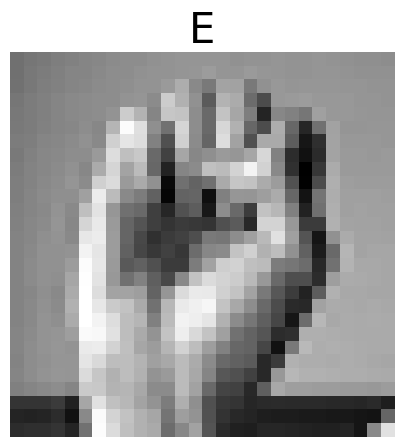

In [14]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [15]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [16]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [17]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well.

In [18]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [19]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [20]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### Baseline model - fully connected network

Before we implement the CNN, let's train a simple fully connected neural network (FCNN) as a baseline. This will help us understand the performance improvement that the CNN architecture provides for image data.

In [21]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512),
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_fcnn = model_fcnn.to(device)

In [22]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_fcnn.parameters())

fcnn_res = train(model_fcnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [00:40<00:00,  2.02s/epoch, train_acc=0.8598, train_loss=0.4024, val_acc=0.7172, val_loss=0.9513]


In [23]:
fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [24]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [25]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [00:55<00:00,  2.76s/epoch, train_acc=0.9985, train_loss=0.0050, val_acc=0.9596, val_loss=0.1745]


In [26]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

## Reflection section

### Which model is better at classifying ASL images?

R= CNN, porque tuvo un test accuracy mas alto, con 9596. Mientras que FCNN fue mas bajo con 0.7172.

### Which model was _faster_ to train?

R= FCNN, con 20 epochs en 40 segundos y el CNN tardo como 55s.

### Plot and compare the learning curves of both models. What do you observe about their training and validation performance over epochs?

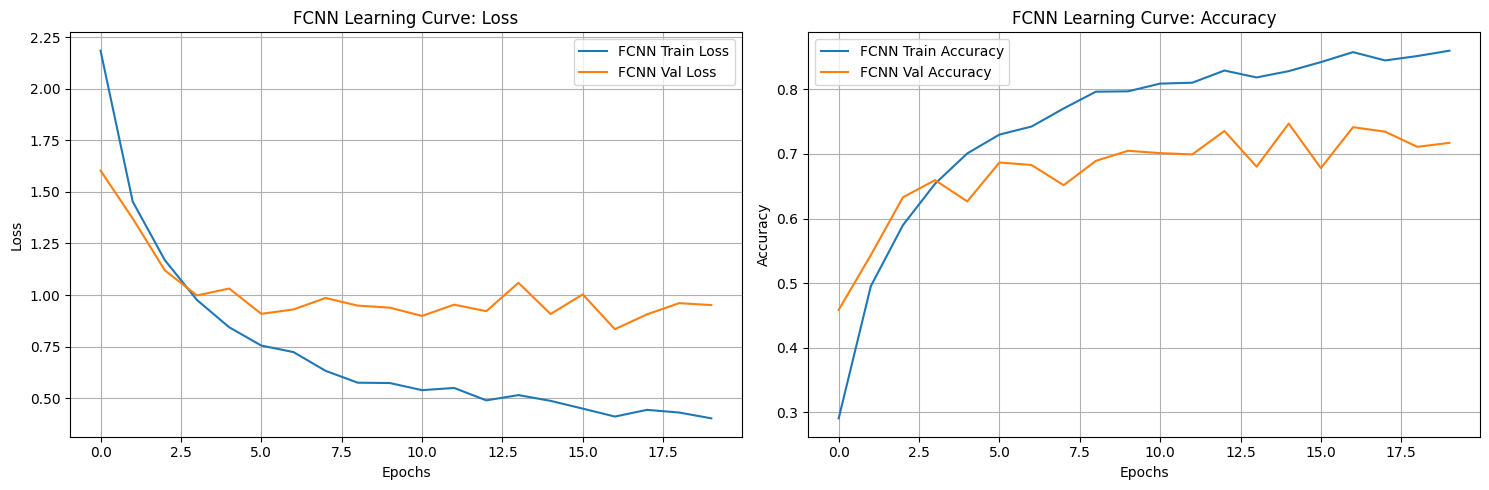

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Plot Training and Validation Loss for FCNN
plt.subplot(1, 2, 1)
plt.plot(fcnn_res['train_loss'], label='FCNN Train Loss')
plt.plot(fcnn_res['val_loss'], label='FCNN Val Loss')
plt.title('FCNN Learning Curve: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training and Validation Accuracy for FCNN
plt.subplot(1, 2, 2)
plt.plot(fcnn_res['train_acc'], label='FCNN Train Accuracy')
plt.plot(fcnn_res['val_acc'], label='FCNN Val Accuracy')
plt.title('FCNN Learning Curve: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


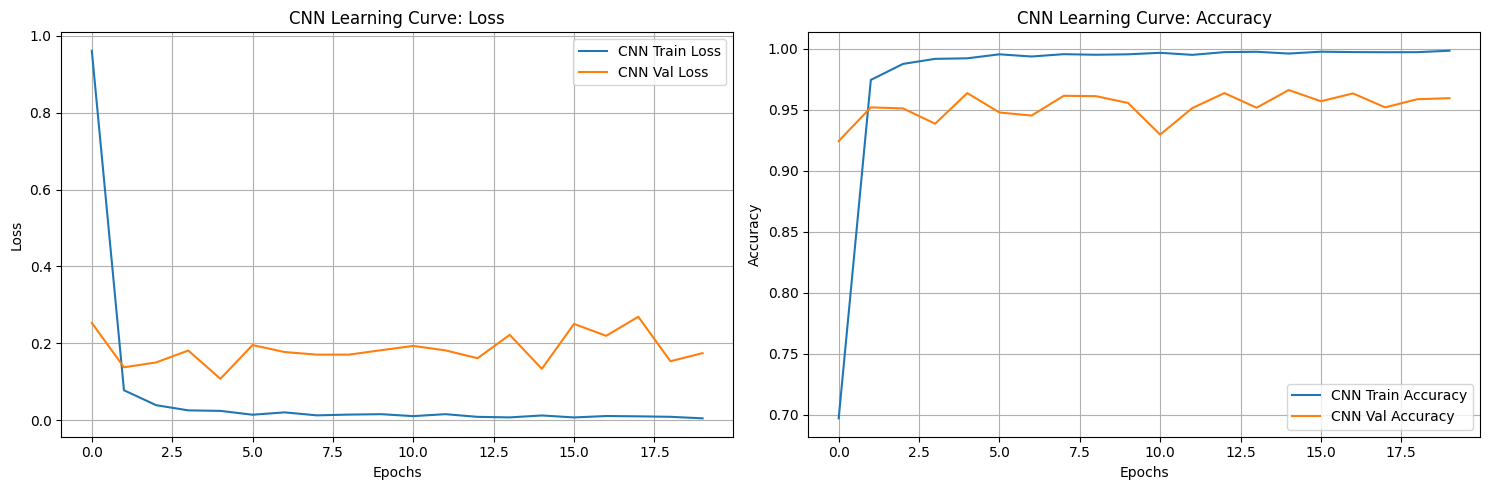

In [28]:
plt.figure(figsize=(15, 5))

# Plot Training and Validation Loss for CNN
plt.subplot(1, 2, 1)
plt.plot(cnn_res['train_loss'], label='CNN Train Loss')
plt.plot(cnn_res['val_loss'], label='CNN Val Loss')
plt.title('CNN Learning Curve: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training and Validation Accuracy for CNN
plt.subplot(1, 2, 2)
plt.plot(cnn_res['train_acc'], label='CNN Train Accuracy')
plt.plot(cnn_res['val_acc'], label='CNN Val Accuracy')
plt.title('CNN Learning Curve: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


R= En las gráfica de FCNN el training loss va bajando mientras que el training accuracy sube, esto dice que el modelo esta aprendiendo del training data. Respecto al validation loss y accuracy, el validation loss comienza bajando luego se anivela e incrementa ligeramente mientras que validation accuracy se nivela también. Hay hay un espacio notable entre el training y el validation accuracy/loss, un ligero overfitting pero no tanto.

En CNN muestra un drecemento en el training loss y un incremento en accuracy, teniendo un buen rendimiento. En validation loss decrementa bastante y validation accuracy incrementa de manera considerable, teniendo un mejor nivel que FCNN. Hay un espacio/brecha enntre el rendimiento pero muestra menos overfitting que el FCNN.

En conclusión CNN muestra ser mejor tanto en entrenamiento como validación, teniendo mejores resultados. Respecto a overfitting, ambos modelos muestran un cierto nivel de overfitting, en FCNN es mas notable, CNN generaliza mejor.

### How many trainable parameters does each model have?

Remember that each convolutional layer has $K \times (C_{in} \times k_h \times k_w + 1)$ parameters, where $K$ is the number of filters, $C_{in}$ is the number of input channels, $k_h$ and $k_w$ are the kernel height and width, and the +1 accounts for the bias term.

Each fully connected layer has $N_{in} \times N_{out} + N_{out}$ parameters, where $N_{in}$ is the number of input features and $N_{out}$ is the number of output features.

In [31]:
# Calcular FCNN parameters
def count_parameters_fcnn(model):
    total_params = 0
    print("\nFCNN Model Parameters")
    for i, layer in enumerate(model.children()):
        if isinstance(layer, nn.Linear):
            N_in = layer.in_features
            N_out = layer.out_features
            params = (N_in * N_out) + N_out # N_in * N_out + bias
            total_params += params
            print(f"Layer {i}: {type(layer).__name__}, Input: {N_in}, Output: {N_out}, Parameters: {params}")
        elif isinstance(layer, nn.Flatten):
            print(f"Layer {i}: {type(layer).__name__}, No trainable parameters")
        elif isinstance(layer, nn.ReLU) or isinstance(layer, nn.Dropout):
            print(f"Layer {i}: {type(layer).__name__}, No trainable parameters")
    print(f"Total Trainable Parameters for FCNN: {total_params}")
    return total_params

fcnn_total_params = count_parameters_fcnn(model_fcnn)



FCNN Model Parameters
Layer 0: Flatten, No trainable parameters
Layer 1: Linear, Input: 784, Output: 512, Parameters: 401920
Layer 2: ReLU, No trainable parameters
Layer 3: Dropout, No trainable parameters
Layer 4: Linear, Input: 512, Output: 512, Parameters: 262656
Layer 5: ReLU, No trainable parameters
Layer 6: Linear, Input: 512, Output: 24, Parameters: 12312
Total Trainable Parameters for FCNN: 676888


In [30]:
# Calcular CNN parameters
def count_parameters_cnn(model):
    total_params = 0
    print("\n--- CNN Model Parameters ---")
    current_h, current_w = IMG_HEIGHT, IMG_WIDTH
    current_channels = IMG_CHANNELS

    for i, layer in enumerate(model.children()):
        if isinstance(layer, nn.Conv2d):
            K = layer.out_channels
            C_in = layer.in_channels
            k_h, k_w = layer.kernel_size
            params = K * (C_in * k_h * k_w + 1) # K * (C_in * k_h * k_w + bias)
            total_params += params
            print(f"Layer {i}: {type(layer).__name__}, K: {K}, C_in: {C_in}, Kernel: {layer.kernel_size}, Parameters: {params}")
            current_channels = K

        elif isinstance(layer, nn.MaxPool2d):
            pool_k = layer.kernel_size
            stride = layer.stride if layer.stride is not None else pool_k
            # Recalculate H, W after MaxPool
            current_h = (current_h - pool_k) // stride + 1
            current_w = (current_w - pool_k) // stride + 1
            print(f"Layer {i}: {type(layer).__name__}, Kernel: {layer.kernel_size}, Stride: {layer.stride}, Output_H: {current_h}, Output_W: {current_w}, No trainable parameters")

        elif isinstance(layer, nn.Flatten):
            # Flatten layer calculates output features based on current_channels, current_h, current_w
            flattened_features = current_channels * current_h * current_w
            print(f"Layer {i}: {type(layer).__name__}, Flattened features: {flattened_features}, No trainable parameters")

        elif isinstance(layer, nn.Linear):
            N_in = layer.in_features
            N_out = layer.out_features
            params = (N_in * N_out) + N_out # N_in * N_out + bias
            total_params += params
            print(f"Layer {i}: {type(layer).__name__}, Input: {N_in}, Output: {N_out}, Parameters: {params}")

        elif isinstance(layer, nn.ReLU) or isinstance(layer, nn.Dropout):
            print(f"Layer {i}: {type(layer).__name__}, No trainable parameters")

    print(f"Total Trainable Parameters for CNN: {total_params}")
    return total_params

cnn_total_params = count_parameters_cnn(model_cnn)



--- CNN Model Parameters ---
Layer 0: Conv2d, K: 25, C_in: 1, Kernel: (3, 3), Parameters: 250
Layer 1: ReLU, No trainable parameters
Layer 2: MaxPool2d, Kernel: 2, Stride: 2, Output_H: 14, Output_W: 14, No trainable parameters
Layer 3: Conv2d, K: 50, C_in: 25, Kernel: (3, 3), Parameters: 11300
Layer 4: ReLU, No trainable parameters
Layer 5: Dropout, No trainable parameters
Layer 6: MaxPool2d, Kernel: 2, Stride: 2, Output_H: 7, Output_W: 7, No trainable parameters
Layer 7: Conv2d, K: 75, C_in: 50, Kernel: (3, 3), Parameters: 33825
Layer 8: ReLU, No trainable parameters
Layer 9: MaxPool2d, Kernel: 2, Stride: 2, Output_H: 3, Output_W: 3, No trainable parameters
Layer 10: Flatten, Flattened features: 675, No trainable parameters
Layer 11: Linear, Input: 675, Output: 512, Parameters: 346112
Layer 12: Dropout, No trainable parameters
Layer 13: ReLU, No trainable parameters
Layer 14: Linear, Input: 512, Output: 24, Parameters: 12312
Total Trainable Parameters for CNN: 403799


R=

**FCNN Trainable Parameters:**
*   Total: **676,888** parameters.

**CNN Trainable Parameters:**
*   Total: **403,799** parameters.

CNN tiene menos paramentros de entrenamiento que FCNN pero aun asi tiene mejor rendimiento, esto por las capas convolucionales ya que son mas efectivas para extraer los features mas importantes

### How do the models compare in terms of overfitting? Why do you think that is the case?

R=  la FCNN mostró un overfitting más notable, con una brecha significativa entre su precisión de entrenamiento y validación. Esto se debe a que trata cada píxel de forma independiente, memorizando detalles del conjunto de entrenamiento y teniendo dificultades para generalizar.

Por otro lado, la CNN demostró una mejor capacidad de generalización y un menor grado de overfitting. Su arquitectura con capas convolucionales y de pooling le permite extraer características relevantes de las imágenes de manera más eficiente, compartiendo pesos y reduciendo la dimensionalidad, lo que la hace más robusta ante datos no vistos.

### Final conclusions and remarks

CNN le gano a  FCNN con un 95.76% de precisión en las pruebas, demostrando la eficacia de las redes convolucionales para imágenes. Aunque FCNN fue más rápida de entrenar con40s que la CNN con 55s para 20 épocas, la CNN logró un mejor rendimiento incluso teniendo menos parámetros debido a la compartición de pesos y el pooling. Respecto al overfitting, la FCNN mostró un grado más pronunciado, mientras que la CNN demostró una mejor capacidad de generalización y menos overfitting. En resumen, las CNNs resultan ser mejor opción  para el reconocimiento de imágenes como el ejemplo visto, ASL,  tienen mejor precisión y mejor generalización.